# Case-08.3:梁剪力設計

依 [ROADMAP.md](../ROADMAP.md) 規劃,延續 Case-08.1(單筋撓曲)、
Case-08.2(雙筋梁+T形梁)。這一課補上剪力設計(`design_stirrups()`)
——桃園案例的 pushover 可信度需要這一步,不能只做撓曲就當配筋完成。

**這一課的開場是一個載重掃描示範**:同一根梁,把均布載重 $w$ 從小
掃到大,同步看撓曲配筋跟剪力配筋各自什麼時候開始吃緊。這個示範
之前在對話裡討論過,但從沒有真的存成檔案(只存在聊天記錄裡),
這次用真正的函式重新產生一次——順便在重建過程中抓到一個
`design_rebar()` 選筋邏輯的真實 bug(見第 2 課),修正後才有這張
乾淨的表。

## 環境設置

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

import os
if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
from rc_design import design_rebar, design_doubly_reinforced, shear_capacity_concrete, design_stirrups

print("rc_design模組已載入")

rc_design模組已載入


## 第 1 課:載重掃描——彎矩、剪力誰先出問題?

固定斷面 $b=30$、$h=50$cm,簡支梁 $L=6$m,把均布載重 $w$ 從小掃到
大(彎矩 $M_u=wL^2/8$、剪力 $V_u=wL/2$ 同步隨 $w$ 增加),同時看
撓曲配筋階段跟剪力夠不夠。

In [2]:
b, h, L, cover = 30.0, 50.0, 6.0, 4.0
d_assumed = h - cover - 0.95 - 2.5/2
phiVc = shear_capacity_concrete(b, d_assumed)

print(f"phiVc(僅混凝土, 假設d={d_assumed:.2f}cm) = {phiVc:.2f} kN\n")

w_list = [20, 25, 30, 35, 45, 60, 90, 140, 180, 200]
results = []

for w in w_list:
    Mu = w*L**2/8
    Vu = w*L/2
    shear_status = "OK" if Vu <= phiVc else "需配筋"

    d_actual = d_assumed
    flex_stage = None
    try:
        r = design_rebar(Mu, b, h, cover=cover)
        d_actual = r['d']
        flex_stage = f"單筋{'雙' if r['layout']['n_layers']==2 else '單'}層"
    except ValueError:
        try:
            r2 = design_doubly_reinforced(Mu, b, h, d_prime_cm=6.0)
            if r2['need_doubly']:
                d_actual = r2['d']
                flex_stage = f"雙筋{'雙' if r2['layout']['n_layers']==2 else '單'}層"
        except ValueError:
            flex_stage = "斷面不足(需加大)"

    if flex_stage == "斷面不足(需加大)":
        results.append(dict(w=w, Mu=Mu, Vu=Vu, shear_status=shear_status,
                             flex_stage=flex_stage, stirrup_info="—(撓曲已需加大斷面)"))
        continue

    stirrup_r = design_stirrups(Vu, b, d_actual)
    if stirrup_r.get('need_stirrups') and stirrup_r.get('ok'):
        stirrup_info = f"{stirrup_r['bar_size']}@{stirrup_r['spacing_cm']:.0f}cm"
    elif not stirrup_r.get('need_stirrups'):
        stirrup_info = "免配筋"
    else:
        stirrup_info = "剪力斷面不足(需加大)"

    results.append(dict(w=w, Mu=Mu, Vu=Vu, shear_status=shear_status,
                         flex_stage=flex_stage, stirrup_info=stirrup_info))

print(f"{'w':>5}{'Mu':>8}{'Vu':>8}{'phiVc':>8}{'剪力狀態':>10}{'撓曲階段':>12}  箍筋/結論")
for r in results:
    print(f"{r['w']:>5}{r['Mu']:>8.1f}{r['Vu']:>8.1f}{phiVc:>8.1f}{r['shear_status']:>10}"
          f"{r['flex_stage']:>12}  {r['stirrup_info']}")

phiVc(僅混凝土, 假設d=43.80cm) = 85.71 kN

    w      Mu      Vu   phiVc      剪力狀態        撓曲階段  箍筋/結論
   20    90.0    60.0    85.7        OK        單筋單層  #3(D10)@20cm
   25   112.5    75.0    85.7        OK        單筋單層  #3(D10)@20cm
   30   135.0    90.0    85.7       需配筋        單筋單層  #3(D10)@20cm
   35   157.5   105.0    85.7       需配筋        單筋單層  #3(D10)@20cm
   45   202.5   135.0    85.7       需配筋        單筋單層  #3(D10)@20cm
   60   270.0   180.0    85.7       需配筋        單筋單層  #4(D13)@20cm
   90   405.0   270.0    85.7       需配筋        雙筋雙層  #4(D13)@10cm
  140   630.0   420.0    85.7       需配筋        雙筋雙層  剪力斷面不足(需加大)
  180   810.0   540.0    85.7       需配筋   斷面不足(需加大)  —(撓曲已需加大斷面)
  200   900.0   600.0    85.7       需配筋   斷面不足(需加大)  —(撓曲已需加大斷面)


**觀察**:剪力在 $w=30$ 就開始需要配筋,這時撓曲還停留在「單筋
單層」最基礎的階段;剪力真正撐不住(連最大箍筋量都不夠、有斜壓
破壞風險)發生在 $w=140$,這時撓曲是「雙筋雙層」;撓曲斷面真正
撐不住(連雙層都排不下)要到 $w=180$ 才發生。**剪力先在中間就出
問題,不是撓曲用完所有招式之後才輪到剪力**——這跟直覺「先把撓曲
那條路走完,最後才考慮剪力」不一樣,規範要求撓曲跟剪力兩條線
同時檢核,不能只顧一邊,原因就在這裡。

## 第 2 課:重建過程中抓到的真實 bug——選筋邏輯的非單調震盪

**這裡誠實記錄一個過程**:第一次重建這張表時,`design_rebar()`
在 $M_u=296$~$323$ 之間出現忽通過忽失敗的怪異行為(不是平滑地
隨 $M_u$ 增加而越來越吃緊)。追查發現:選筋函式 `choose_bars_
with_layout()` 原本只比「過量比例」,沒有優先考慮「層數」——導致
$M_u$ 增加、需求鋼筋量增加時,有時反而換到一個能單層排下的鋼筋
尺寸,讓有效深度 $d$ 不減反增,造成非單調的接受/拒絕邊界。

修正:排序改成先比層數(單層優先於雙層),層數相同才比過量比例。
下面重跑一次當初抓到問題的那個範圍,確認現在是平滑的。

In [3]:
print(f"{'Mu':>6}{'結果':>8}{'n_passes':>10}{'d':>8}{'eps_t':>10}{'層數'}")
for Mu_test in [280, 290, 296, 300, 305, 310, 315, 320, 323, 324, 325]:
    try:
        r = design_rebar(Mu_test, b, h, cover=cover)
        print(f"{Mu_test:>6}{'成功':>8}{r['n_passes']:>10}{r['d']:>8.2f}{r['eps_t']:>10.5f}{r['layout']['n_layers']}層")
    except ValueError:
        print(f"{Mu_test:>6}{'失敗':>8}")

# 驗證: 現在應該是平滑遞減到某個邊界後乾淨失敗, 不是忽通過忽失敗
eps_t_values = []
for Mu_test in [280, 290, 296, 300, 305, 310, 315, 320, 323]:
    r = design_rebar(Mu_test, b, h, cover=cover)
    eps_t_values.append(r['eps_t'])

is_monotonic = all(eps_t_values[i] >= eps_t_values[i+1] for i in range(len(eps_t_values)-1))
assert is_monotonic, "eps_t應該隨Mu增加單調遞減, 選筋邏輯修正後不應該再出現非單調"
print("\n[PASS] eps_t隨Mu增加單調遞減, 選筋邏輯的非單調震盪已修正")

    Mu      結果  n_passes       d     eps_t層數
   280      成功         1   43.80   0.006541層
   290      成功         1   43.80   0.006151層
   296      成功         1   43.80   0.005931層
   300      成功         1   43.80   0.005781層
   305      成功         1   43.80   0.005611層
   310      成功         1   43.80   0.005441層
   315      成功         1   43.80   0.005281層
   320      成功         1   43.80   0.005121層
   323      成功         1   43.80   0.005031層
   324      失敗
   325      失敗

[PASS] eps_t隨Mu增加單調遞減, 選筋邏輯的非單調震盪已修正


## 第 3 課:`design_stirrups()` 獨立驗證

用選定的箍筋規格反推 $\phi V_n$,對照函式輸出——跟前面幾課同一套
精神,不是只信任公式解本身。

In [4]:
def verify_stirrups(bar_area_single, spacing_cm, bw_cm, d_cm, fc=280.0, fyv=2800.0, phi=0.75):
    Vc = 0.53*math.sqrt(fc)*bw_cm*d_cm
    Av = 2*bar_area_single
    Vs = Av*fyv*d_cm/spacing_cm
    return phi*(Vc+Vs)*9.80665e-3


test_cases = [
    dict(Vu_kN=105.0, bw_cm=30.0, d_cm=43.8),
    dict(Vu_kN=180.0, bw_cm=30.0, d_cm=43.8),
    dict(Vu_kN=250.0, bw_cm=30.0, d_cm=41.32),
]
bar_areas = {"#3(D10)": 0.71, "#4(D13)": 1.267}

print(f"{'Vu':>6}{'選筋':>12}{'phiVn(函式)':>14}{'phiVn(獨立驗證)':>16}{'差異'}")
for case in test_cases:
    r = design_stirrups(**case)
    if not r.get('ok'):
        print(f"{case['Vu_kN']:>6}  設計失敗: {r['reason']}")
        continue
    Ab = bar_areas[r['bar_size']]
    phiVn_check = verify_stirrups(Ab, r['spacing_cm'], case['bw_cm'], case['d_cm'])
    diff = abs(phiVn_check - r['phiVn'])/r['phiVn']
    print(f"{case['Vu_kN']:>6}{r['bar_size']+'@'+str(r['spacing_cm'])+'cm':>12}"
          f"{r['phiVn']:>14.2f}{phiVn_check:>16.2f}{diff:>8.4%}")
    assert diff < 0.001, f"獨立驗證應該完全吻合(同一條公式的兩種算法): 差異{diff:.4%}"

print("\n[PASS] design_stirrups()跟獨立驗證完全吻合(差異<0.1%, 這是同一公式的")
print("兩種算法, 理論上就該分毫不差, 不是纖維vs應變相容法那種本來就有系統性")
print("差距的比較)")

    Vu          選筋     phiVn(函式)     phiVn(獨立驗證)差異
 105.0#3(D10)@20cm        149.75          149.75 0.0000%
 180.0#4(D13)@20cm        200.00          200.00 0.0000%
 250.0#4(D13)@10cm        296.49          296.49 0.0000%

[PASS] design_stirrups()跟獨立驗證完全吻合(差異<0.1%, 這是同一公式的
兩種算法, 理論上就該分毫不差, 不是纖維vs應變相容法那種本來就有系統性
差距的比較)


## 第 4 課:剪力容量對照圖

把第 1 課的載重掃描畫成圖,直接看 $V_u$ 什麼時候超過 $\phi V_c$、
$\phi V_n$。

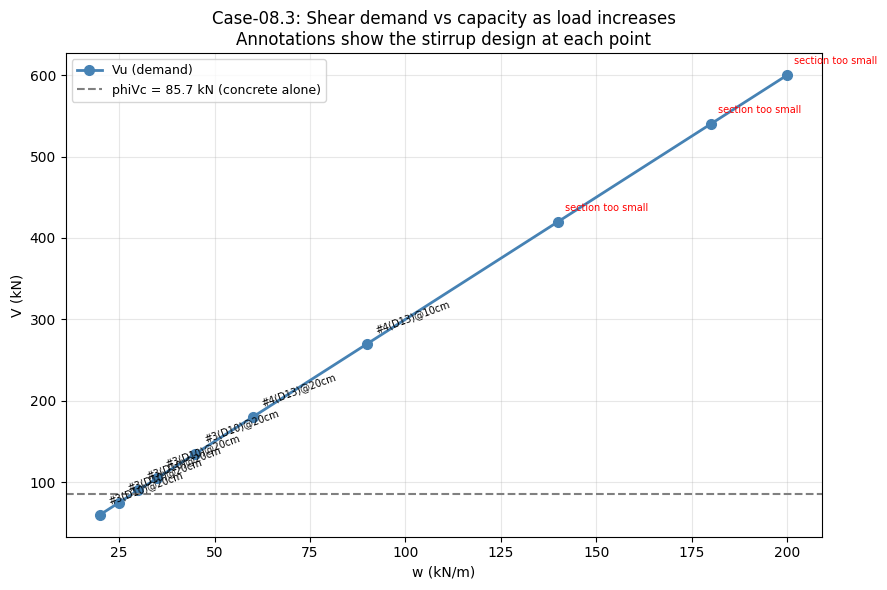

In [5]:
fig, ax = plt.subplots(figsize=(9,6))
w_arr = np.array([r['w'] for r in results])
Vu_arr = np.array([r['Vu'] for r in results])

ax.plot(w_arr, Vu_arr, 'o-', color='steelblue', lw=2, ms=7, label='Vu (demand)')
ax.axhline(phiVc, color='gray', ls='--', lw=1.5, label=f'phiVc = {phiVc:.1f} kN (concrete alone)')

# 標出各點的箍筋設計結果
for r in results:
    if 'D10' in r['stirrup_info'] or 'D13' in r['stirrup_info']:
        ax.annotate(r['stirrup_info'], (r['w'], r['Vu']), fontsize=7,
                    textcoords="offset points", xytext=(5,8), rotation=20)
    elif '需加大' in r['stirrup_info']:
        ax.annotate('section too small', (r['w'], r['Vu']), fontsize=7, color='red',
                    textcoords="offset points", xytext=(5,8))

ax.set_xlabel('w (kN/m)')
ax.set_ylabel('V (kN)')
ax.set_title('Case-08.3: Shear demand vs capacity as load increases\nAnnotations show the stirrup design at each point')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 第 5 課:設計摘要——用第 1 課 $w=35$ 那個案例示範

跟 08.1/08.2 同一套精神,取第 1 課掃描裡 $w=35$(剪力剛好開始
需要配筋)那個案例,印出完整摘要。

In [6]:
from rc_design import print_design_summary

w_demo = 35.0
Mu_demo = w_demo*L**2/8
Vu_demo = w_demo*L/2
r_flex = design_rebar(Mu_demo, b, h, cover=cover)
r_shear = design_stirrups(Vu_demo, b, r_flex['d'])

util_shear = print_design_summary(
    kind=f"Case-08.3 箍筋設計(w={w_demo}kN/m案例)",
    geometry=dict(bw=f"{b:.0f} cm", h=f"{h:.0f} cm", d=f"{r_flex['d']:.2f} cm(有效深度, 沿用撓曲設計結果)"),
    material=dict(fc="280 kgf/cm^2", fyv="2800 kgf/cm^2(箍筋用SD280, 跟主筋fy不同)"),
    demand=dict(Vu=f"{Vu_demo:.2f} kN"),
    result=r_shear,
    capacity_value=r_shear['phiVn'],
    demand_value=r_shear['Vu_demand'],
)

assert util_shear <= 1.0, "使用率超過100%代表設計不合格"
print(f"\n[PASS] 使用率 {util_shear:.1%} <= 100%, 箍筋設計合格")

設計摘要: Case-08.3 箍筋設計(w=35.0kN/m案例)

[幾何]
  bw = 30 cm
  h = 50 cm
  d = 43.80 cm(有效深度, 沿用撓曲設計結果)

[材料]
  fc = 280 kgf/cm^2
  fyv = 2800 kgf/cm^2(箍筋用SD280, 跟主筋fy不同)

[設計需求]
  Vu = 105.00 kN

[選筋後實際供給]
  箍筋規格: #3(D10)
  箍筋間距 = 20 cm

[合格判定]
  供給容量 = 149.75
  設計需求 = 105.00
  使用率(需求/供給) = 70.1%
  結論: 合格(供給 >= 需求)

[PASS] 使用率 70.1% <= 100%, 箍筋設計合格


## 第 6 課:完整設計例題(獨立一格)——箍筋設計+立面圖

不依賴前面任何 cell 的變數。**箍筋一般不畫斷面圖**(斷面畫出來只有
一個矩形圈,看不出設計重點是什麼)——業界通用的是畫**立面圖(側視)**,
直接看沿梁長箍筋的間距分布,這才是箍筋設計真正要交代的東西。

設計摘要: Case-08.3 箍筋設計

[幾何]
  bw = 30.0 cm
  h = 50.0 cm
  有效深度 d = 43.8 cm

[材料]
  fc' = 280.0 kgf/cm^2
  fyv = 2800.0 kgf/cm^2(箍筋用SD280)

[設計需求]
  設計剪力 Vu = 105.0 kN

[選筋後實際供給]
  箍筋規格: #3(D10)
  箍筋間距 = 20 cm

[合格判定]
  供給容量 = 149.75
  設計需求 = 105.00
  使用率(需求/供給) = 70.1%
  結論: 合格(供給 >= 需求)


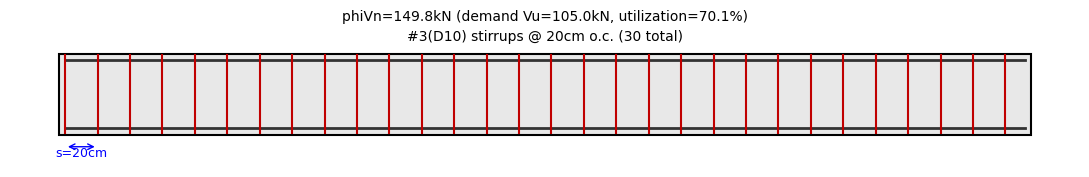

In [7]:
# ============================================================
# 完整設計例題：梁剪力設計(箍筋)
# ============================================================
import os
import matplotlib.pyplot as plt

if not os.path.exists('rc_design.py'):
    !wget -q https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py

from rc_design import design_stirrups, draw_stirrup_elevation, print_design_summary

# ---------- 題目條件（你可以改這些數字）----------
bw_cm     = 30.0       # 梁寬 (cm)
h_cm      = 50.0       # 梁高 (cm)
d_cm      = 43.8       # 有效深度 (cm) <- 沿用撓曲設計結果, 不是重新假設
L_cm      = 600.0      # 梁跨度 (cm), 只用來畫立面圖, 不影響設計本身
cover     = 4.0
fc        = 280.0      # 混凝土抗壓強度 (kgf/cm^2)
fyv       = 2800.0     # 箍筋降伏強度 (kgf/cm^2), 常用比主筋低的等級(SD280)
Vu_kN     = 105.0      # 設計剪力需求 (kN)  <- 需求強度

# ---------- 執行設計 ----------
r = design_stirrups(
    Vu_kN=Vu_kN, bw_cm=bw_cm, d_cm=d_cm, fc=fc, fyv=fyv
)

if not r.get('ok'):
    print(f"設計失敗: {r['reason']}")
elif not r['need_stirrups']:
    print(f"Vu<=0.5*phiVc, 理論上不需要剪力筋: {r['reason']}")
else:
    util = print_design_summary(
        kind="Case-08.3 箍筋設計",
        geometry={"bw": f"{bw_cm} cm", "h": f"{h_cm} cm", "有效深度 d": f"{d_cm} cm"},
        material={"fc'": f"{fc} kgf/cm^2", "fyv": f"{fyv} kgf/cm^2(箍筋用SD280)"},
        demand={"設計剪力 Vu": f"{Vu_kN} kN"},
        result=r,
        capacity_value=r['phiVn'],
        demand_value=r['Vu_demand'],
    )

    fig, ax = plt.subplots(figsize=(11, 3))
    draw_stirrup_elevation(
        L_cm=L_cm, h_cm=h_cm, cover_cm=cover,
        spacing_cm=r['spacing_cm'], bar_size=r['bar_size'],
        title=f"phiVn={r['phiVn']:.1f}kN (demand Vu={Vu_kN}kN, utilization={util:.1%})",
        ax=ax
    )
    plt.tight_layout()
    plt.show()

### 換一組廠商指定的箍筋規格

跟 Case-08.1 主筋的做法一樣,`design_stirrups()` 的 `stirrup_table`
參數可以直接傳自訂的箍筋規格表——同一題,換成假設某公司只有 #3
一種箍筋可用(不備 #4):

In [8]:
# 自訂箍筋表: 只列公司實際備料的規格(格式同主筋: 名稱: 單根面積cm^2)
company_stirrup_table = {"#3(D10)": 0.71}
Vu_demo2 = 150.0   # 換一個會真正選到#4的需求值, 才看得出限定規格的差異

r_std = design_stirrups(Vu_kN=Vu_demo2, bw_cm=b, d_cm=r_flex['d'])
r_company = design_stirrups(Vu_kN=Vu_demo2, bw_cm=b, d_cm=r_flex['d'],
                              stirrup_table=company_stirrup_table)

print(f"標準表(#3/#4都開放): {r_std['bar_size']}@{r_std['spacing_cm']:.0f}cm, "
      f"phiVn={r_std['phiVn']:.1f}kN")
print(f"公司限定表(僅#3):     {r_company['bar_size']}@{r_company['spacing_cm']:.0f}cm, "
      f"phiVn={r_company['phiVn']:.1f}kN")
print(f"\n兩者都>=需求{Vu_demo2}kN, 都合格——公司沒有#4可用時, #3的間距")
print(f"從標準表的{r_std['spacing_cm']:.0f}cm收緊到{r_company['spacing_cm']:.0f}cm,")
print(f"靠加密取代大直徑, 用料量比較多但一樣是合格設計")

標準表(#3/#4都開放): #4(D13)@20cm, phiVn=200.0kN
公司限定表(僅#3):     #3(D10)@15cm, phiVn=171.1kN

兩者都>=需求150.0kN, 都合格——公司沒有#4可用時, #3的間距
從標準表的20cm收緊到15cm,
靠加密取代大直徑, 用料量比較多但一樣是合格設計


## 小結

- `shear_capacity_concrete()`:混凝土本身的剪力容量 $\phi V_c$
- `design_stirrups()`:箍筋設計(雙肢垂直箍筋),含最小鋼筋量、最大
  間距、Vs 上限(斜壓破壞)三項檢核,獨立驗證吻合(差異<0.1%)
- 載重掃描證實:剪力常常比撓曲更早出問題,兩條線要同時檢核
- 過程中抓到並修正 `choose_bars_with_layout()` 的非單調選筋 bug
  (層數優先於過量比例),這個修正已經回饋進 `rc_design.py`,
  Case-08.1/08.2 跟 `tests/` 都已經用修正後版本重新驗證過
- Case-08 到這裡加上柱 P-M 設計就收尾,不繼續往下擴張(見
  ROADMAP.md 的說明)